# Ante-hoc attention pipeline (NORCIA pretrained → Switzerland fine-tuning)

This notebook follows the same attention-token workflow as `attention_token_based.ipynb`, then loads `models/NORCIA_best_model.pt` and fine-tunes on the Switzerland (Diemtigen) foreshock-vs-aftershock data.


In [1]:
from pathlib import Path
import random
import math
import os

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

c:\Users\miche\OneDrive\Desktop\EQML Project\XAI-CH-antehoc\XAI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys, site
print("Python:", sys.executable)
print("Version:", sys.version)

import torch
print("torch file:", torch.__file__)
print("torch version:", torch.__version__)
print("torch.version.cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("device count:", torch.cuda.device_count())
    print("device 0:", torch.cuda.get_device_name(0))

Python: c:\Users\miche\OneDrive\Desktop\EQML Project\XAI-CH-antehoc\XAI\Scripts\python.exe
Version: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
torch file: c:\Users\miche\OneDrive\Desktop\EQML Project\XAI-CH-antehoc\XAI\Lib\site-packages\torch\__init__.py
torch version: 2.11.0+cu126
torch.version.cuda: 12.6
cuda available: True
device count: 1
device 0: NVIDIA GeForce GTX 1650 with Max-Q Design


In [3]:
# -----------------------------
# Reproducibility + device
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce GTX 1650 with Max-Q Design


In [4]:
# -----------------------------
# Paths and dataset assumptions (Switzerland / Diemtigen)
# -----------------------------
data_root = Path("diemtigen_data")
h5_path = data_root / "events_mainshocks_foreshocks_aftershocks_15sec_23days.h5"
info_path = data_root / "info_h5_events_mainshocks_foreshocks_aftershocks_15sec_23days.csv"
pretrained_path = Path("models/NORCIA_best_model.pt")

assert h5_path.exists(), f"Missing: {h5_path}"
assert info_path.exists(), f"Missing: {info_path}"
assert pretrained_path.exists(), f"Missing pretrained checkpoint: {pretrained_path}"

label_map = {"foreshock": 0, "aftershock": 1}
channels = {"E": "HHE", "N": "HHN", "Z": "HHZ"}

info = pd.read_csv(info_path)
info_fa = info[info["event_type"].isin(label_map)].copy().reset_index(drop=True)
info_fa["label"] = info_fa["event_type"].map(label_map)
print("Foreshock/aftershock events in Switzerland CSV:", len(info_fa))
info_fa[["event_id", "event_type", "label"]].head()


Foreshock/aftershock events in CSV: 2341


,event_id,event_type,label
0,20140417015156,foreshock,0
1,20140417023407,foreshock,0
2,20140417030217,foreshock,0
3,20140417030538,foreshock,0
4,20140417030638,foreshock,0


In [5]:
# -----------------------------
# Signal loading helpers
# -----------------------------
def get_event_traces(h5f, event_id: str, channels_map: dict):
    """
    Returns dict {'E','N','Z'} -> np.ndarray and sampling rate.
    """
    g = h5f[str(event_id)]
    tr = g["traces"]
    keys = list(tr.keys())

    # sampling rate from first available trace
    sr = float(tr[keys[0]].attrs.get("sampling_rate", np.nan))

    out = {}
    for comp, chan in channels_map.items():
        candidates = [k for k in keys if k.endswith(chan)]
        out[comp] = np.array(tr[candidates[0]][:]) if candidates else None
    return out, sr


def zscore_per_channel(x):
    # x shape: (3, n_samples)
    mu = x.mean(axis=1, keepdims=True)
    sd = x.std(axis=1, keepdims=True) + 1e-8
    return (x - mu) / sd

In [6]:
# -----------------------------
# Tokenization strategy
# -----------------------------
# We split each event waveform into overlapping windows (tokens).
# Each token = flattened [3 channels x window_samples].

WINDOW_SEC = 0.50      # 500 ms per token
STRIDE_SEC = 0.25      # 50% overlap
MAX_EVENTS = None      # set e.g. 2000 for faster prototyping

samples = []
labels = []
meta = []

with h5py.File(h5_path, "r") as h5f:
    rows = info_fa if MAX_EVENTS is None else info_fa.iloc[:MAX_EVENTS]

    for _, r in tqdm(rows.iterrows(), total=len(rows), desc="Loading events"):
        eid = str(r["event_id"])
        if eid not in h5f:
            continue

        traces, sr = get_event_traces(h5f, eid, channels)
        if any(traces[c] is None for c in ["E", "N", "Z"]):
            continue

        L = min(traces["E"].size, traces["N"].size, traces["Z"].size)
        arr = np.stack([
            traces["E"][:L].astype(np.float32),
            traces["N"][:L].astype(np.float32),
            traces["Z"][:L].astype(np.float32),
        ], axis=0)

        arr = zscore_per_channel(arr)

        w = int(round(WINDOW_SEC * sr))
        s = int(round(STRIDE_SEC * sr))
        if w < 4 or s < 1 or L < w:
            continue

        token_list = []
        t0_list = []
        for start in range(0, L - w + 1, s):
            tok = arr[:, start:start + w].reshape(-1)
            token_list.append(tok)
            t0_list.append(start / sr)

        if len(token_list) < 2:
            continue

        tokens = np.stack(token_list, axis=0)  # [n_tokens, 3*w]
        samples.append(tokens)
        labels.append(int(r["label"]))
        meta.append({
            "event_id": eid,
            "event_type": r["event_type"],
            "sampling_rate": sr,
            "n_tokens": tokens.shape[0],
            "token_start_sec": np.array(t0_list, dtype=np.float32),
        })

print("Usable events:", len(samples))
print("Token shape for first event:", samples[0].shape if samples else None)

Loading events: 100%|██████████| 2341/2341 [00:22<00:00, 103.12it/s]

Usable events: 2341
Token shape for first event: (59, 180)


In [7]:
# Ensure fixed token length across dataset (truncate to global minimum)
min_tokens = min(x.shape[0] for x in samples)
print("Minimum tokens across events:", min_tokens)

X = np.stack([x[:min_tokens] for x in samples], axis=0).astype(np.float32)
y = np.array(labels, dtype=np.int64)

# keep aligned metadata and token times
token_times = np.stack([m["token_start_sec"][:min_tokens] for m in meta], axis=0)

print("X shape [N,T,D]:", X.shape)
print("Class counts:", dict(pd.Series(y).value_counts().sort_index()))

Minimum tokens across events: 59
X shape [N,T,D]: (2341, 59, 180)
Class counts: {0: np.int64(1169), 1: np.int64(1172)}


In [8]:
X_train, X_temp, y_train, y_temp, tt_train, tt_temp = train_test_split(
    X, y, token_times, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test, tt_val, tt_test = train_test_split(
    X_temp, y_temp, tt_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (1638, 59, 180) Val: (351, 59, 180) Test: (352, 59, 180)


In [9]:
class TokenDataset(Dataset):
    def __init__(self, X, y, token_times):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        self.token_times = torch.from_numpy(token_times).float()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.token_times[idx]

BATCH_SIZE = 64 if device.type == "cuda" else 32

train_ds = TokenDataset(X_train, y_train, tt_train)
val_ds = TokenDataset(X_val, y_val, tt_val)
test_ds = TokenDataset(X_test, y_test, tt_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [10]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model=128, n_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(d_model)
        hidden = int(d_model * mlp_ratio)
        self.ff = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x, need_weights=False):
        h = self.norm1(x)
        attn_out, attn_w = self.attn(
            h, h, h,
            need_weights=need_weights,
            average_attn_weights=False,
        )
        x = x + attn_out
        x = x + self.ff(self.norm2(x))
        return x, attn_w


class SeismicTokenTransformer(nn.Module):
    def __init__(self, input_dim, n_tokens, d_model=96, n_heads=4, n_layers=2, dropout=0.25):
        super().__init__()
        self.n_tokens = n_tokens
        self.input_proj = nn.Linear(input_dim, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_tokens + 1, d_model))
        self.embed_dropout = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            EncoderBlock(d_model=d_model, n_heads=n_heads, dropout=dropout)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, 2),
        )

        self.cached_attn = []
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x, return_attn=False):
        # x: [B,T,Din]
        B, T, _ = x.shape
        x = self.input_proj(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embed[:, :T + 1, :]
        x = self.embed_dropout(x)

        self.cached_attn = []
        for blk in self.blocks:
            x, attn_w = blk(x, need_weights=return_attn)
            if return_attn:
                self.cached_attn.append(attn_w)  # [B,H,T+1,T+1]

        x = self.norm(x)
        logits = self.head(x[:, 0])
        return logits



In [11]:
# -----------------------------
# Fine-tuning configuration (load NORCIA checkpoint first)
# -----------------------------
input_dim = X_train.shape[-1]
n_tokens = X_train.shape[1]

model = SeismicTokenTransformer(
    input_dim=input_dim,
    n_tokens=n_tokens,
    d_model=96,
    n_heads=4,
    n_layers=2,
    dropout=0.25,
).to(device)

def load_pretrained_weights(model, ckpt_path, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    if isinstance(ckpt, dict):
        if "state_dict" in ckpt:
            state = ckpt["state_dict"]
        elif "model_state_dict" in ckpt:
            state = ckpt["model_state_dict"]
        else:
            state = ckpt
    else:
        state = ckpt

    cleaned = {}
    for k, v in state.items():
        cleaned[k.replace("module.", "")] = v

    incompatible = model.load_state_dict(cleaned, strict=False)
    print("Loaded pretrained checkpoint:", ckpt_path)
    print("Missing keys:", incompatible.missing_keys)
    print("Unexpected keys:", incompatible.unexpected_keys)

load_pretrained_weights(model, pretrained_path, device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

EPOCHS = 30
PATIENCE = 8
LAMBDA_ENTROPY = 1e-3  # set 0.0 to disable sparsity pressure
AUGMENT_NOISE_STD = 0.01
AUGMENT_TOKEN_DROP_P = 0.05

print(model)


SeismicTokenTransformer(
  (input_proj): Linear(in_features=180, out_features=96, bias=True)
  (embed_dropout): Dropout(p=0.25, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x EncoderBlock(
      (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=96, out_features=96, bias=True)
      )
      (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (ff): Sequential(
        (0): Linear(in_features=96, out_features=192, bias=True)
        (1): GELU(approximate='none')
        (2): Dropout(p=0.25, inplace=False)
        (3): Linear(in_features=192, out_features=96, bias=True)
        (4): Dropout(p=0.25, inplace=False)
      )
    )
  )
  (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Dropout(p=0.25, inplace=False)
    (1): Linear(in_features=96, out_features=2, bias=True)
  )
)


In [12]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total, trainable = count_parameters(model)

print(f"Total parameters: {total:,}")
print(f"Trainable parameters: {trainable:,}")

Total parameters: 173,186
Trainable parameters: 173,186


In [99]:
def cls_attention_entropy(attn_weights):
    """
    attn_weights: list of [B,H,S,S], S=T+1.
    Uses last layer CLS->token attention entropy (normalized).
    """
    if not attn_weights:
        return torch.tensor(0.0, device=device)

    a = attn_weights[-1].mean(dim=1)      # [B,S,S]
    cls_to_tok = a[:, 0, 1:]              # [B,T]
    p = cls_to_tok / (cls_to_tok.sum(dim=-1, keepdim=True) + 1e-8)
    ent = -(p * (p + 1e-8).log()).sum(dim=-1)
    ent = ent / math.log(p.shape[-1] + 1e-8)
    return ent.mean()


def augment_batch(xb, noise_std=0.015, token_drop_p=0.10):
    """Mild token-space augmentation to reduce overfitting."""
    x_aug = xb
    if noise_std > 0:
        x_aug = x_aug + noise_std * torch.randn_like(x_aug)
    if token_drop_p > 0:
        keep = (torch.rand(x_aug.shape[:2], device=x_aug.device) > token_drop_p).unsqueeze(-1)
        x_aug = x_aug * keep
    return x_aug


def run_epoch(model, loader, train=True):
    model.train(train)
    losses = []
    probs_all, y_all = [], []

    for xb, yb, _ in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if train:
            xb = augment_batch(xb, noise_std=AUGMENT_NOISE_STD, token_drop_p=AUGMENT_TOKEN_DROP_P)
            optimizer.zero_grad()

        logits = model(xb, return_attn=(train and LAMBDA_ENTROPY > 0))
        loss = criterion(logits, yb)

        if train and LAMBDA_ENTROPY > 0:
            ent = cls_attention_entropy(model.cached_attn)
            loss = loss + LAMBDA_ENTROPY * ent

        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        losses.append(loss.item())

        p = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        probs_all.append(p)
        y_all.append(yb.detach().cpu().numpy())

    probs_all = np.concatenate(probs_all)
    y_all = np.concatenate(y_all)
    pred = (probs_all >= 0.5).astype(int)

    metrics = {
        "loss": float(np.mean(losses)),
        "acc": accuracy_score(y_all, pred),
        "f1": f1_score(y_all, pred),
        "auc": roc_auc_score(y_all, probs_all),
    }
    return metrics



In [100]:
best_val_auc = -np.inf
best_state = None
history = []
wait = 0

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(model, train_loader, train=True)
    va = run_epoch(model, val_loader, train=False)

    scheduler.step(va["auc"])
    row = {"epoch": epoch, **{f"tr_{k}": v for k,v in tr.items()}, **{f"va_{k}": v for k,v in va.items()}}
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"tr_loss={tr['loss']:.4f} tr_auc={tr['auc']:.3f} | "
        f"va_loss={va['loss']:.4f} va_auc={va['auc']:.3f}"
    )

    if va["auc"] > best_val_auc:
        best_val_auc = va["auc"]
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

hist_df = pd.DataFrame(history)
hist_df.tail()

finetuned_out = Path("models/NORCIA_finetuned_on_switzerland.pt")
finetuned_out.parent.mkdir(parents=True, exist_ok=True)
torch.save(model.state_dict(), finetuned_out)
print(f"Saved fine-tuned weights to: {finetuned_out}")



Epoch 01 | tr_loss=0.7417 tr_auc=0.481 | va_loss=0.6976 va_auc=0.502
Epoch 02 | tr_loss=0.6992 tr_auc=0.548 | va_loss=0.7134 va_auc=0.540
Epoch 03 | tr_loss=0.7065 tr_auc=0.512 | va_loss=0.6992 va_auc=0.526
Epoch 04 | tr_loss=0.7125 tr_auc=0.515 | va_loss=0.7043 va_auc=0.533
Epoch 05 | tr_loss=0.6986 tr_auc=0.518 | va_loss=0.6932 va_auc=0.522
Epoch 06 | tr_loss=0.6970 tr_auc=0.519 | va_loss=0.6923 va_auc=0.531
Epoch 07 | tr_loss=0.6926 tr_auc=0.544 | va_loss=0.6916 va_auc=0.535
Epoch 08 | tr_loss=0.6929 tr_auc=0.537 | va_loss=0.6925 va_auc=0.534
Epoch 09 | tr_loss=0.6969 tr_auc=0.532 | va_loss=0.6935 va_auc=0.537
Epoch 10 | tr_loss=0.6931 tr_auc=0.546 | va_loss=0.6927 va_auc=0.542
Epoch 11 | tr_loss=0.6869 tr_auc=0.573 | va_loss=0.7067 va_auc=0.538
Epoch 12 | tr_loss=0.6921 tr_auc=0.556 | va_loss=0.7048 va_auc=0.545
Epoch 13 | tr_loss=0.6840 tr_auc=0.578 | va_loss=0.6903 va_auc=0.547
Epoch 14 | tr_loss=0.6812 tr_auc=0.583 | va_loss=0.6981 va_auc=0.552
Epoch 15 | tr_loss=0.6807 tr_auc=0

,epoch,tr_loss,tr_acc,tr_f1,tr_auc,va_loss,va_acc,va_f1,va_auc
21,22,0.658186,0.611111,0.594009,0.649702,0.707806,0.535613,0.370656,0.556266
22,23,0.665735,0.589133,0.577527,0.630519,0.706731,0.535613,0.394052,0.554935
23,24,0.660350,0.597680,0.560959,0.643200,0.704013,0.538462,0.390977,0.558247
24,25,0.652594,0.608669,0.595073,0.661724,0.709004,0.535613,0.389513,0.558994
25,26,0.652413,0.612943,0.595663,0.655284,0.713692,0.538462,0.372093,0.566786


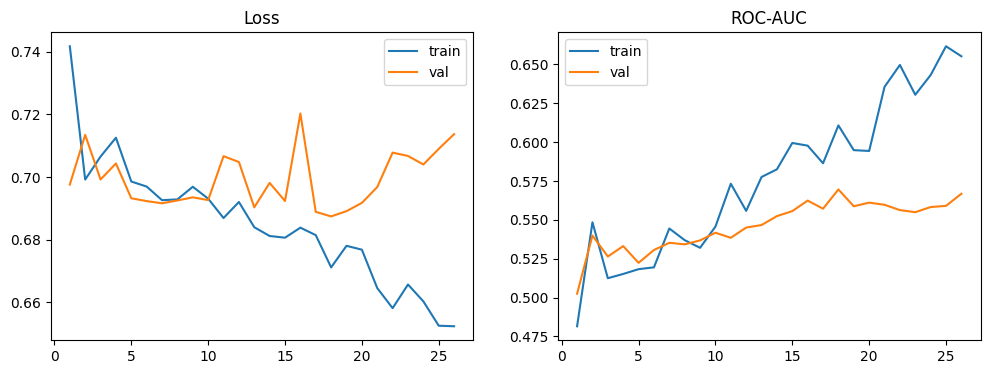

In [101]:
# Training curves
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist_df["epoch"], hist_df["tr_loss"], label="train")
ax[0].plot(hist_df["epoch"], hist_df["va_loss"], label="val")
ax[0].set_title("Loss")
ax[0].legend()

ax[1].plot(hist_df["epoch"], hist_df["tr_auc"], label="train")
ax[1].plot(hist_df["epoch"], hist_df["va_auc"], label="val")
ax[1].set_title("ROC-AUC")
ax[1].legend()
plt.show()

In [102]:
def predict_proba(model, loader, return_attn=False):
    model.eval()
    probs, ys = [], []
    attn_batches = []
    x_batches, t_batches = [], []

    with torch.no_grad():
        for xb, yb, tb in loader:
            xb = xb.to(device)
            logits = model(xb, return_attn=return_attn)
            p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

            probs.append(p)
            ys.append(yb.numpy())
            x_batches.append(xb.cpu().numpy())
            t_batches.append(tb.numpy())

            if return_attn:
                # save last layer attention for this batch
                a = model.cached_attn[-1].detach().cpu().numpy()  # [B,H,S,S]
                attn_batches.append(a)

    out = {
        "probs": np.concatenate(probs),
        "y": np.concatenate(ys),
        "x": np.concatenate(x_batches),
        "times": np.concatenate(t_batches),
    }
    if return_attn:
        out["attn_last"] = np.concatenate(attn_batches)
    return out

{'accuracy': 0.5227272727272727, 'f1': 0.48466257668711654, 'roc_auc': 0.5371255165289256}
              precision    recall  f1-score   support

   foreshock       0.52      0.60      0.56       176
  aftershock       0.53      0.45      0.48       176

    accuracy                           0.52       352
   macro avg       0.52      0.52      0.52       352
weighted avg       0.52      0.52      0.52       352



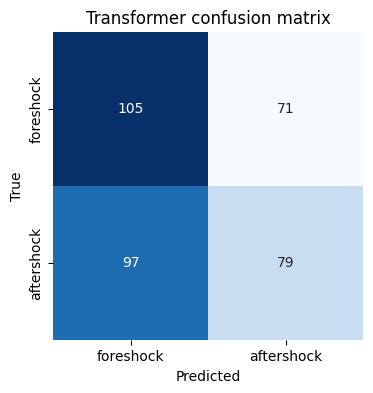

In [103]:
# Test evaluation
res = predict_proba(model, test_loader, return_attn=True)
y_true = res["y"]
proba = res["probs"]
y_pred = (proba >= 0.5).astype(int)

print({
    "accuracy": accuracy_score(y_true, y_pred),
    "f1": f1_score(y_true, y_pred),
    "roc_auc": roc_auc_score(y_true, proba),
})
print(classification_report(y_true, y_pred, target_names=["foreshock", "aftershock"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["foreshock", "aftershock"],
            yticklabels=["foreshock", "aftershock"])
plt.title("Transformer confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## Token-level attention inspection
We inspect **last-layer CLS attention** to tokens.
- We average heads.
- We normalize over tokens.
- We compare with the event waveform timeline (token start times).

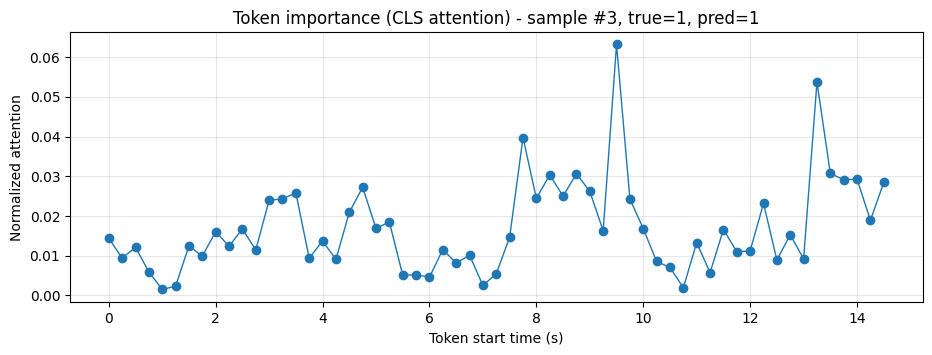

In [104]:
def cls_token_importance_from_last(attn_last):
    """
    attn_last: [H,S,S] for one sample, S=T+1.
    returns token importance [T] from CLS -> token attention.
    """
    a = attn_last.mean(axis=0)      # [S,S]
    imp = a[0, 1:]                  # CLS to tokens
    imp = imp / (imp.sum() + 1e-12)
    return imp

# pick a correctly classified sample for visualization
idx_candidates = np.where(y_true == y_pred)[0]
idx = int(idx_candidates[0]) if len(idx_candidates) else 0

x_i = res["x"][idx]                # [T,D]
t_i = res["times"][idx]            # [T]
attn_i = res["attn_last"][idx]     # [H,S,S]
imp_i = cls_token_importance_from_last(attn_i)

plt.figure(figsize=(11, 3.5))
plt.plot(t_i, imp_i, marker="o", linewidth=1)
plt.title(f"Token importance (CLS attention) - sample #{idx}, true={y_true[idx]}, pred={y_pred[idx]}")
plt.xlabel("Token start time (s)")
plt.ylabel("Normalized attention")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
correct_mask = (y_true == y_pred)
imp_all = np.stack([cls_token_importance_from_last(a) for a in res["attn_last"]], axis=0)
t_axis = res["times"][0]

plt.figure(figsize=(11, 4))
for cls, name, color in [(0, "foreshock", "tab:blue"), (1, "aftershock", "tab:orange")]:
    m = correct_mask & (y_true == cls)
    if m.sum() == 0:
        continue
    mean_imp = imp_all[m].mean(axis=0)
    std_imp = imp_all[m].std(axis=0)
    plt.plot(t_axis, mean_imp, label=f"{name} (n={m.sum()})", color=color)
    plt.fill_between(t_axis, mean_imp - std_imp, mean_imp + std_imp, color=color, alpha=0.2)

plt.title("NRCA mean CLS-attention profiles on correct test samples")
plt.xlabel("Token start time (s)")
plt.ylabel("Normalized attention")
plt.grid(alpha=0.3)
plt.legend()
plt.show()


## Faithfulness tests (removal / insertion)
We quantify whether high-attention tokens actually matter for prediction:

- **Removal**: progressively zero top-attention tokens; confidence should drop faster than random.
- **Insertion**: start from all-zero tokens and add top-attention tokens; confidence should rise faster than random.

This is reported on test data and averaged.

In [105]:
def batched_predict_positive(model, X_np, bs=128):
    model.eval()
    outs = []
    with torch.no_grad():
        for i in range(0, len(X_np), bs):
            xb = torch.from_numpy(X_np[i:i+bs]).float().to(device)
            logits = model(xb, return_attn=False)
            p = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            outs.append(p)
    return np.concatenate(outs)


def get_rankings_from_attention(model, X_np, bs=128):
    model.eval()
    rankings = []
    with torch.no_grad():
        for i in range(0, len(X_np), bs):
            xb = torch.from_numpy(X_np[i:i+bs]).float().to(device)
            _ = model(xb, return_attn=True)
            a = model.cached_attn[-1].detach().cpu().numpy()  # [B,H,S,S]
            for j in range(a.shape[0]):
                imp = cls_token_importance_from_last(a[j])
                rankings.append(np.argsort(-imp))
    return np.stack(rankings)


def faithfulness_curves(model, X_np, y_np, rankings, steps=10, seed=42):
    rng = np.random.default_rng(seed)
    N, T, D = X_np.shape

    base_p = batched_predict_positive(model, X_np)

    frac_grid = np.linspace(0.0, 1.0, steps + 1)
    rem_attn, rem_rand = [], []
    ins_attn, ins_rand = [], []

    # For insertion, start from zero baseline
    X_zero = np.zeros_like(X_np)

    for frac in tqdm(frac_grid, desc="Faithfulness steps"):
        k = int(round(frac * T))

        Xr_attn = X_np.copy()
        Xr_rand = X_np.copy()
        Xi_attn = X_zero.copy()
        Xi_rand = X_zero.copy()

        for i in range(N):
            idx_attn = rankings[i][:k]
            idx_rand = rng.choice(T, size=k, replace=False) if k > 0 else np.array([], dtype=int)

            # Removal
            Xr_attn[i, idx_attn, :] = 0.0
            Xr_rand[i, idx_rand, :] = 0.0

            # Insertion
            Xi_attn[i, idx_attn, :] = X_np[i, idx_attn, :]
            Xi_rand[i, idx_rand, :] = X_np[i, idx_rand, :]

        p_r_attn = batched_predict_positive(model, Xr_attn)
        p_r_rand = batched_predict_positive(model, Xr_rand)
        p_i_attn = batched_predict_positive(model, Xi_attn)
        p_i_rand = batched_predict_positive(model, Xi_rand)

        # Track confidence for the true class target direction
        # Here we use class-1 probability as primary curve.
        rem_attn.append(p_r_attn.mean())
        rem_rand.append(p_r_rand.mean())
        ins_attn.append(p_i_attn.mean())
        ins_rand.append(p_i_rand.mean())

    return {
        "frac": frac_grid,
        "base_mean_p1": base_p.mean(),
        "rem_attn": np.array(rem_attn),
        "rem_rand": np.array(rem_rand),
        "ins_attn": np.array(ins_attn),
        "ins_rand": np.array(ins_rand),
    }

Faithfulness steps: 100%|██████████| 11/11 [00:02<00:00,  4.60it/s]


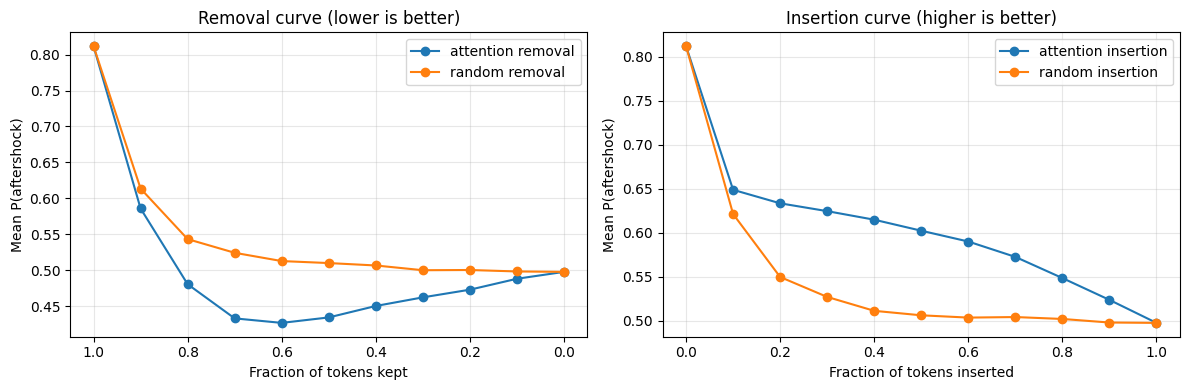

Base mean P(class=1): 0.4976
Removal gap at 50% tokens kept (attn-rand): -0.0757
Insertion gap at 50% tokens inserted (attn-rand): 0.0961


In [106]:
# Compute rankings on test set and evaluate faithfulness
rankings_test = get_rankings_from_attention(model, X_test)
faith = faithfulness_curves(model, X_test, y_test, rankings_test, steps=10, seed=SEED)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(faith["frac"], faith["rem_attn"], marker="o", label="attention removal")
plt.plot(faith["frac"], faith["rem_rand"], marker="o", label="random removal")
plt.gca().invert_xaxis()
plt.title("Removal curve (lower is better)")
plt.xlabel("Fraction of tokens kept")
plt.ylabel("Mean P(aftershock)")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1,2,2)
plt.plot(faith["frac"], faith["ins_attn"], marker="o", label="attention insertion")
plt.plot(faith["frac"], faith["ins_rand"], marker="o", label="random insertion")
plt.title("Insertion curve (higher is better)")
plt.xlabel("Fraction of tokens inserted")
plt.ylabel("Mean P(aftershock)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

print("Base mean P(class=1):", round(float(faith["base_mean_p1"]), 4))
print("Removal gap at 50% tokens kept (attn-rand):", round(float(faith["rem_attn"][5] - faith["rem_rand"][5]), 4))
print("Insertion gap at 50% tokens inserted (attn-rand):", round(float(faith["ins_attn"][5] - faith["ins_rand"][5]), 4))

## What to report in experiments
For transparent ante-hoc claims, report at least:
1. Classification metrics (AUC/F1/accuracy) on held-out test.
2. Token attention examples for both classes.
3. Faithfulness curves and attention-vs-random gaps.
4. Sensitivity to hyperparameters (`WINDOW_SEC`, `STRIDE_SEC`, model size).
5. Whether entropy regularization was used (`LAMBDA_ENTROPY`).

## Suggested next iterations
- Compare raw-window tokens vs wavelet-packet tokens.
- Add subject/event-level grouped split if leakage is possible.
- Add calibration (temperature scaling) for reliable probabilities.
- Contrast with EBM feature model in a common benchmark table.